In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x = np.load('../data/processed/tracks_scaled.npy')
clabels = np.load('../data/processed/cluster_labels.npy')
track_genres = np.load('../data/processed/track_genres.npy', allow_pickle=True)

AUDIO_FEATURES = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

print("x shape:", x.shape)
print("Labels shape:", clabels.shape)
print("Genres shape:", track_genres.shape)
print("Sample genres:", track_genres[:5])


x shape: (114000, 8)
Labels shape: (114000,)
Genres shape: (114000,)
Sample genres: ['acoustic' 'acoustic' 'acoustic' 'acoustic' 'acoustic']


In [4]:
# Dataframe with features and cluster label
df = pd.DataFrame(x, columns=AUDIO_FEATURES)
df['cluster'] = clabels

# Mean of each feature per cluster
profile = df.groupby('cluster')[AUDIO_FEATURES].mean().round(3)
print(profile.to_string())

         danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence  tempo
cluster                                                                                             
0              -0.266   0.431       -0.057        -0.067            -0.297     2.532    0.148  0.034
1               0.775   0.319       -0.141        -0.276            -0.448    -0.278    0.905 -0.136
2              -1.122  -1.770       -0.355         1.507             2.153    -0.325   -1.031 -0.601
3              -0.275  -1.053       -0.400         1.105            -0.451    -0.307   -0.390 -0.308
4              -0.548   0.687       -0.076        -0.790            -0.413    -0.105   -0.398  0.578
5               0.563   0.119        3.216         0.170            -0.425     0.359    0.200 -0.073
6               0.095   0.489       -0.123        -0.738             1.993    -0.204   -0.521  0.191


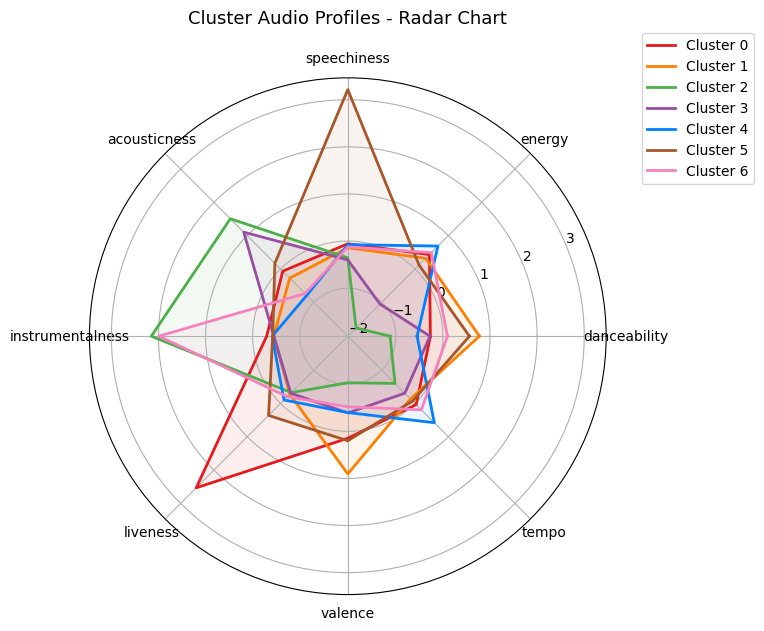

In [5]:
from matplotlib.patches import FancyArrowPatch

colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#984ea3', '#0080ff', '#a65628', '#f781bf']

# Radar chart setup
categories = AUDIO_FEATURES
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cid in range(7):
    v = profile.loc[cid, AUDIO_FEATURES].tolist()
    v += v[:1]  # Complete the loop
    ax.plot(angles, v, color=colors[cid], linewidth=2, label=f'Cluster {cid}')
    ax.fill(angles, v, color=colors[cid], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('Cluster Audio Profiles - Radar Chart', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../outputs/figures/07_cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Build a DataFrame with cluster labels and genres
df_genres = pd.DataFrame({
    'cluster': clabels,
    'genre': track_genres
})

# Top 5 genres per cluster by track count
for cid in range(7):
    subset = df_genres[df_genres['cluster'] == cid]
    top_genres = subset['genre'].value_counts().head(5)
    print(f"\nCluster {cid} ({len(subset):,} tracks):")
    for genre, count in top_genres.items():
        print(f"  {genre:<30} {count:>5} tracks  ({count/len(subset)*100:.1f}%)")


Cluster 0 (8,421 tracks):
  pagode                           537 tracks  (6.4%)
  sertanejo                        474 tracks  (5.6%)
  samba                            432 tracks  (5.1%)
  mpb                              287 tracks  (3.4%)
  forro                            224 tracks  (2.7%)

Cluster 1 (33,149 tracks):
  salsa                            810 tracks  (2.4%)
  latino                           772 tracks  (2.3%)
  reggaeton                        768 tracks  (2.3%)
  reggae                           752 tracks  (2.3%)
  latin                            745 tracks  (2.2%)

Cluster 2 (7,737 tracks):
  new-age                          777 tracks  (10.0%)
  classical                        709 tracks  (9.2%)
  ambient                          707 tracks  (9.1%)
  sleep                            656 tracks  (8.5%)
  piano                            561 tracks  (7.3%)

Cluster 3 (22,445 tracks):
  romance                          794 tracks  (3.5%)
  jazz                   

In [7]:
# Build Summary Table
archetypes = {
    0: 'Live and Brazilian Rhythms',
    1: 'Danceable & Upbeat',
    2: 'Serene Instrumentals',
    3: 'Acoustic & Melodic',
    4: 'High-Energy Rock & Metal',
    5: 'Spoken Word & Vocal-Heavy',
    6: 'Electronic Instrumentals'
}

summary = profile.copy()
summary.insert(0, 'archetype', [archetypes[i] for i in summary.index])
summary.insert(1, 'track_count', [len(df[df['cluster'] == i]) for i in summary.index])

summary.to_csv('../outputs/tables/cluster_summary.csv')
print(summary[['archetype', 'track_count']].to_string())

                          archetype  track_count
cluster                                         
0        Live and Brazilian Rhythms         8421
1                Danceable & Upbeat        33149
2              Serene Instrumentals         7737
3                Acoustic & Melodic        22445
4          High-Energy Rock & Metal        24203
5         Spoken Word & Vocal-Heavy         6274
6          Electronic Instrumentals        11771
